<a href="https://colab.research.google.com/github/jupiterbouncer/Sankofa-Symptom-Checker/blob/feature%2Fsubair-cleandata/05_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import os
from google.colab import drive, files

print(os.getcwd())
drive.mount("/content/drive")

/content
Mounted at /content/drive


## LOADING MODEL, ENCODER AND TEST DATA

In [ ]:
rf = joblib.load('/content/drive/MyDrive/SE-dataset/random_forest.pkl')
le = joblib.load('/content/drive/MyDrive/SE-dataset/label_encoder.pkl')

In [ ]:
# reloading test split
df = pd.read_csv(
    "/content/drive/MyDrive/SE-dataset/cleaned_diseases_symptoms.csv"
)
X = df.drop(columns = ['diseases'])
y = le.fit_transform(df['diseases'])

from sklearn.model_selection import train_test_split
_, X_temp, _, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

y_pred = rf.predict(X_test)

## OVERALL METRICS

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Macro-F1:  {f1_score(y_test, y_pred, average='macro', zero_division=0)}")
print(f"Weighted-F1: {f1_score(y_test, y_pred, average='weighted', zero_division=0)}")

Accuracy: 0.7491747548898852
Macro-F1:  0.655683988354471
Weighted-F1: 0.7863015081107105


## PER-CLASS REPORT (by F1)

In [ ]:
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T.iloc[:-3]  # drop avg rows
report_df = report_df.sort_values('f1-score', ascending=False)

print("\nTop 10 best predicted diseases:")
print(report_df.head(10)[['precision', 'recall', 'f1-score', 'support']])

print("\nBottom 10 worst predicted diseases:")
print(report_df.tail(10)[['precision', 'recall', 'f1-score', 'support']])


Top 10 best predicted diseases:
                           precision  recall  f1-score  support
thyroid disease                  1.0    1.00  1.000000      1.0
aplastic anemia                  1.0    1.00  1.000000      6.0
primary kidney disease           1.0    1.00  1.000000      3.0
bladder cancer                   1.0    1.00  1.000000     13.0
spina bifida                     1.0    1.00  1.000000      8.0
injury to the hip                1.0    1.00  1.000000      1.0
hypercalcemia                    1.0    1.00  1.000000      1.0
dislocation of the finger        1.0    1.00  1.000000      3.0
neonatal jaundice                1.0    1.00  1.000000      4.0
sialoadenitis                    1.0    0.95  0.974359     60.0

Bottom 10 worst predicted diseases:
                                    precision  recall  f1-score  support
dislocation of the wrist                  0.0     0.0       0.0      2.0
chronic kidney disease                    0.0     0.0       0.0      1.0
galacto

## F1 SCORE DISTRIBUTION

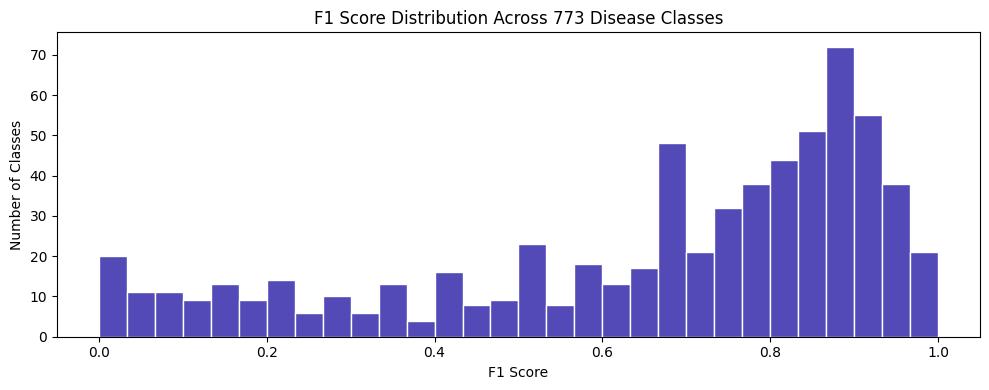

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(report_df['f1-score'], bins=30, color='#534ab7', edgecolor='white')
plt.title('F1 Score Distribution Across 773 Disease Classes')
plt.xlabel('F1 Score')
plt.ylabel('Number of Classes')
plt.tight_layout()
plt.show()

## CONFUSION MATRIX (top 20 diseases only)

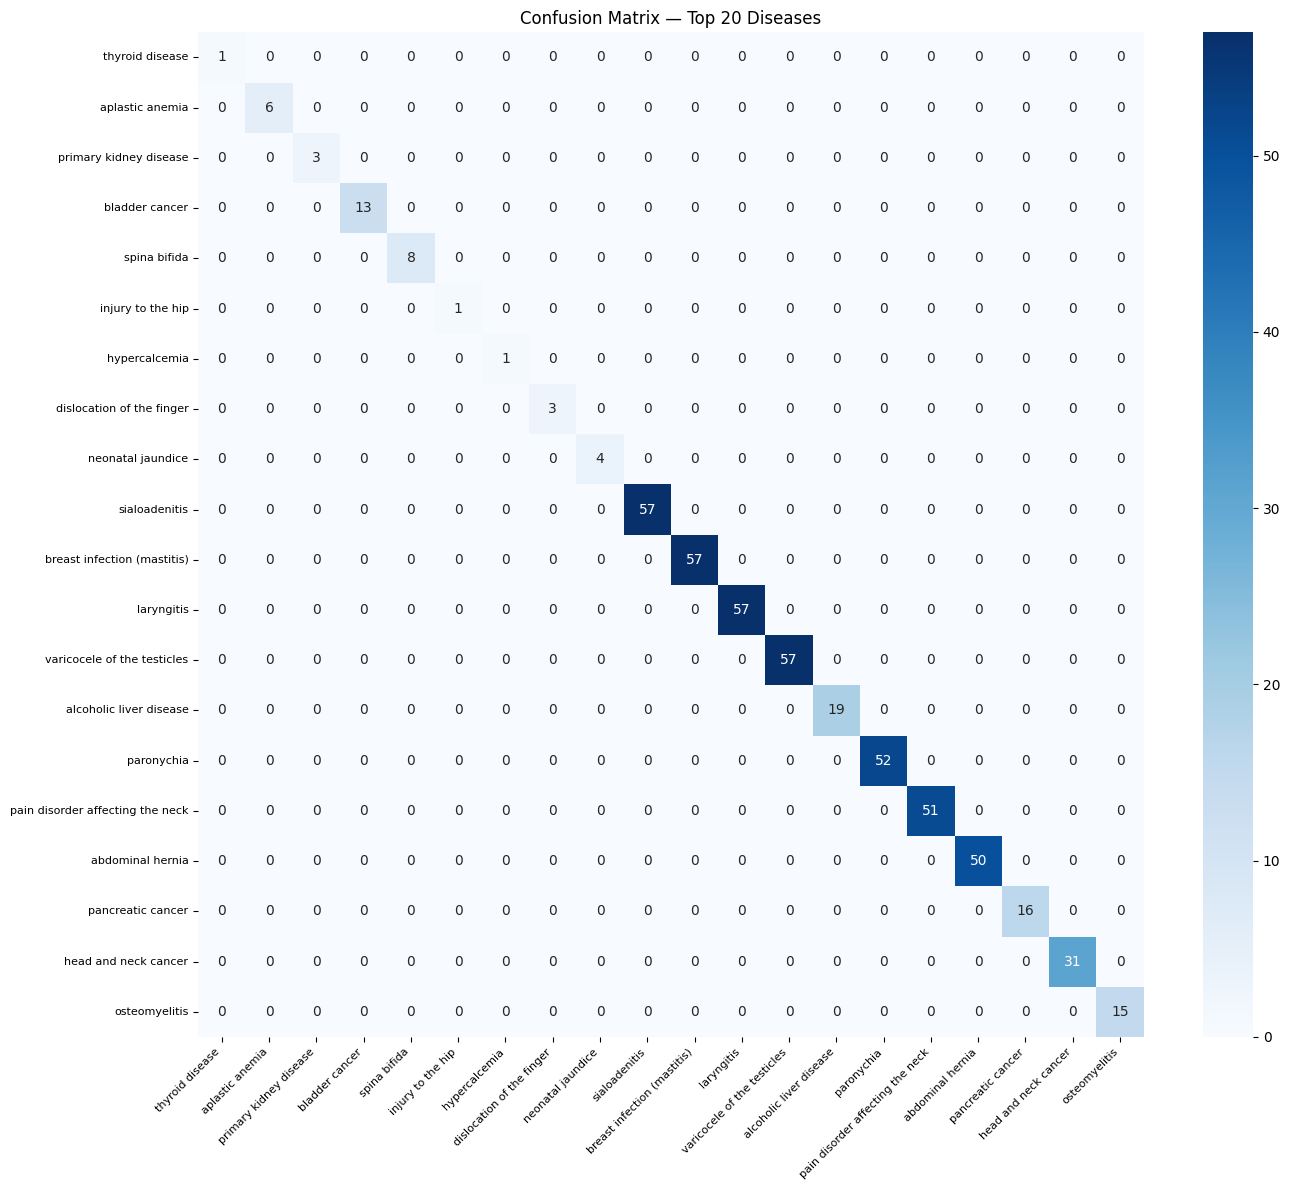

In [ ]:
top20 = report_df.head(20).index.tolist()
top20_idx = [le.transform([d])[0] for d in top20]

mask = np.isin(y_test, top20_idx)
y_test_top = y_test[mask]
y_pred_top = y_pred[mask]

cm = confusion_matrix(y_test_top, y_pred_top, labels=top20_idx)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top20, yticklabels=top20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Confusion Matrix — Top 20 Diseases')
plt.tight_layout()
plt.show()

## FEATURE IMPORTANCE (top 20 symptoms)

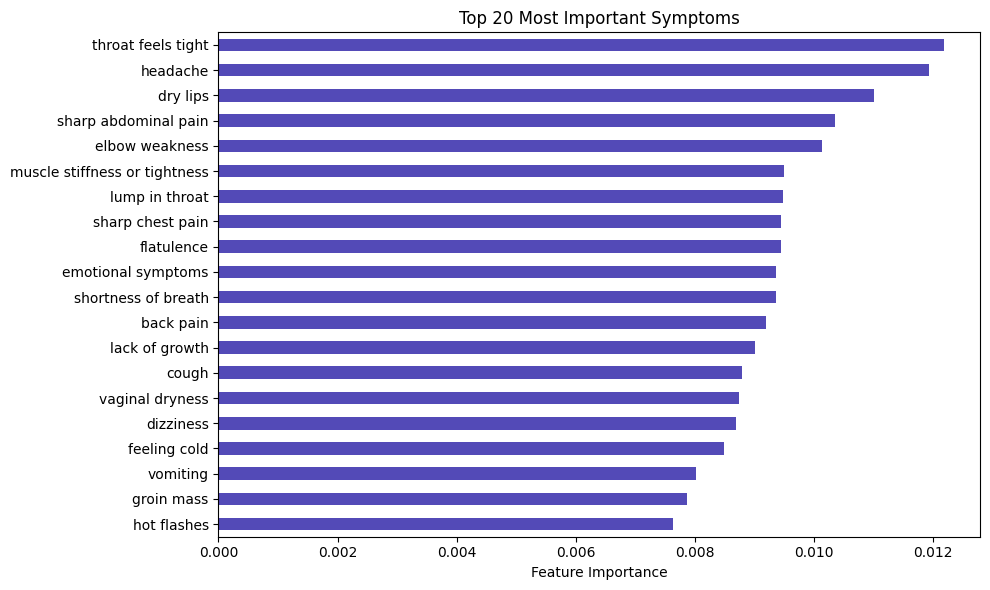

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_symptoms = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_symptoms.plot(kind='barh', color='#534ab7')
plt.title('Top 20 Most Important Symptoms')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## BASELINE COMPARISON

In [ ]:
majority_class = np.bincount(y_test).argmax()
baseline_acc = accuracy_score(y_test, np.full_like(y_test, majority_class))
print(f"\nBaseline (majority class) accuracy: {baseline_acc}")
print(f"Random Forest improvement over baseline: {accuracy_score(y_test, y_pred) - baseline_acc}")


Baseline (majority class) accuracy: 0.002956101886978371
Random Forest improvement over baseline: 0.7462186530029068


A 74.62% improvement over a baseline model reflects a massive jump in predictive performance. Considering the size of the dataset, the Random Forest captured highly complex, non-linear feature interactions